In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [28]:
# Configuration and paths
mac = 20
under_expression = True

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""loftee_categories""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
…,…,…,…,…
"""5utr_annotator""","""five_prime_utr_variant_consequ…","""#00A99D""","""5UTR Frameshift""",1
"""5utr_annotator""","""five_prime_utr_variant_consequ…","""#FFD700""","""5UTR Start Gain""",1
"""5utr_annotator""","""five_prime_utr_variant_consequ…","""#FFA500""","""5UTR Stop Gain""",1


In [3]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),
        (pl.col('consequence_missense_variant') == True),
    )
    .with_columns(
        structured_domain = pl.col('ted_domain'),
        non_structured_domain = pl.col('ted_domain') == False,
    )
    .select(
        set(['id', 'region', 'structured_domain', 'non_structured_domain'])
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


region,structured_domain,id,non_structured_domain
str,bool,str,bool
"""ENSG00000204843""",false,"""chr2:74370671:T:G""",true
"""ENSG00000171988""",true,"""chr10:63380416:A:C""",false
"""ENSG00000169174""",true,"""chr1:55063472:T:C""",false
"""ENSG00000102996""",true,"""chr16:58039939:C:T""",false
"""ENSG00000159307""",false,"""chr22:43258222:T:C""",true
…,…,…,…
"""ENSG00000119471""",true,"""chr9:112404080:G:A""",false
"""ENSG00000060339""",true,"""chr10:68754730:G:C""",false
"""ENSG00000163217""",true,"""chr2:68866556:G:A""",false


In [4]:
anno[['structured_domain', 'non_structured_domain']].sum()

structured_domain,non_structured_domain
u64,u64
525719,704611


In [5]:
melted_anno = (
    anno

    .unpivot(
        index=["id", "region"],
        on=['structured_domain', 'non_structured_domain'],
        variable_name="annotation",
        value_name="annotation_score"
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,bool
"""chr2:74370671:T:G""","""ENSG00000204843""","""structured_domain""",false
"""chr10:63380416:A:C""","""ENSG00000171988""","""structured_domain""",true
"""chr1:55063472:T:C""","""ENSG00000169174""","""structured_domain""",true
"""chr16:58039939:C:T""","""ENSG00000102996""","""structured_domain""",true
"""chr22:43258222:T:C""","""ENSG00000159307""","""structured_domain""",false
…,…,…,…
"""chr9:112404080:G:A""","""ENSG00000119471""","""non_structured_domain""",false
"""chr10:68754730:G:C""","""ENSG00000060339""","""non_structured_domain""",false
"""chr2:68866556:G:A""","""ENSG00000163217""","""non_structured_domain""",false


In [6]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
    .select(['region', 'phenotype', 'loftee_corr_dir'])
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,loftee_corr_dir
str,str,f64
"""ENSG00000084674""","""ldl_direct_int""",-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.0
…,…,…
"""ENSG00000115977""","""sitting_height_int""",-1.0
"""ENSG00000119574""","""standing_height_int""",-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",-1.0


In [11]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect()
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:178571014:C:T""","""leg_fatfree_mass_left_int""",-0.04929,7
"""chr17:50187944:C:T""","""basal_metabolic_rate_int""",0.992802,3
"""chr2:178741274:T:C""","""seated_height_int""",0.461834,9
"""chr15:58893289:C:A""","""arm_fat_mass_right_int""",0.632569,1
"""chr2:203125973:G:C""","""seated_height_int""",0.39507,12
…,…,…,…
"""chr1:41116980:A:G""","""standing_height_int""",-0.524603,4
"""chr20:3800774:G:C""","""leg_predicted_mass_right_int""",0.229128,7
"""chr2:23752075:T:C""","""basal_metabolic_rate_int""",0.209874,2


In [ ]:
id_region = anno.select(['id', 'region']).unique()

pheno_anno = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df, on=['region', 'phenotype'], how='inner')
    .join(melted_anno, on=['id', 'region'], how='inner')
    .with_columns(
        mean_pheno_value_dircor = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(-pl.col('mean_pheno_value'))
            .otherwise(pl.col('mean_pheno_value'))
    )
    .select(['id', 'region', 'annotation', 'annotation_score', 'mean_pheno_value_dircor'])
)

pheno_anno

id,region,annotation,annotation_score,mean_pheno_value_dircor
str,str,str,bool,f32
"""chr1:55063472:T:C""","""ENSG00000169174""","""structured_domain""",true,-1.08523
"""chr22:43258222:T:C""","""ENSG00000159307""","""structured_domain""",false,0.044214
"""chr1:100723217:G:T""","""ENSG00000162692""","""structured_domain""",true,1.06777
"""chr19:39473487:G:A""","""ENSG00000196235""","""structured_domain""",false,0.305783
"""chr5:76693399:A:G""","""ENSG00000145703""","""structured_domain""",true,0.919225
…,…,…,…,…
"""chr17:49763993:G:A""","""ENSG00000121104""","""non_structured_domain""",true,-1.436295
"""chr3:44841208:A:C""","""ENSG00000163808""","""non_structured_domain""",true,0.343518
"""chr3:66383040:C:G""","""ENSG00000144749""","""non_structured_domain""",true,1.137861


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 351'. Pick better value with 'binwidth'.


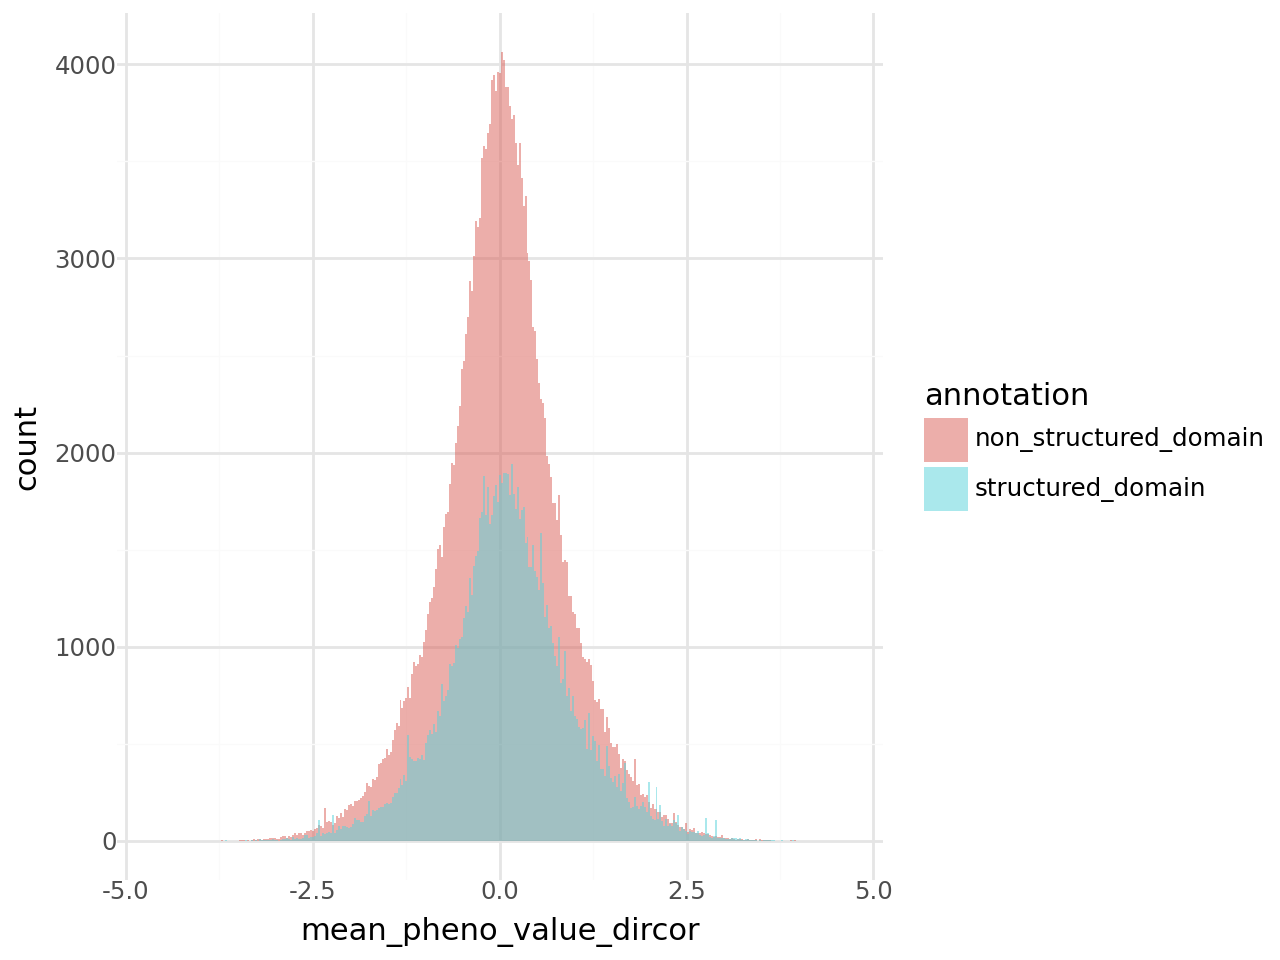

In [27]:
(
    ggplot(pheno_anno.filter(pl.col('annotation_score')==True), aes(x='mean_pheno_value_dircor', fill='annotation'))
    + geom_histogram(position='identity', alpha=0.5)
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [8]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
    .select(['region', 'phenotype', 'loftee_corr_dir'])
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr_dir
str,str,f64
"""ENSG00000131471""","""ENSG00000131471_olink""",1.0
"""ENSG00000143382""","""ENSG00000143382_olink""",1.0
"""ENSG00000099994""","""ENSG00000099994_olink""",1.0
"""ENSG00000213927""","""ENSG00000213927_olink""",1.0
"""ENSG00000174080""","""ENSG00000174080_olink""",1.0
…,…,…
"""ENSG00000168079""","""ENSG00000168079_olink""",1.0
"""ENSG00000149564""","""ENSG00000149564_olink""",1.0
"""ENSG00000141736""","""ENSG00000141736_olink""",1.0


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect()
)

olink_appv

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr1:21831513:T:A""","""ENSG00000142798_olink""",0.769834,1
"""chr15:75688928:G:T""","""ENSG00000173546_olink""",-3.485898,1
"""chr19:55517373:C:G""","""ENSG00000179954_olink""",0.42362,1
"""chr1:21873392:T:C""","""ENSG00000142798_olink""",-1.254142,1
"""chr18:50974549:C:A""","""ENSG00000141642_olink""",-0.567493,1
…,…,…,…
"""chr11:100002034:G:A""","""ENSG00000149972_olink""",-0.306812,1
"""chr7:108240045:G:A""","""ENSG00000091129_olink""",0.429412,3
"""chr18:74559350:A:G""","""ENSG00000150656_olink""",1.484271,1


In [29]:
id_region = anno.select(['id', 'region']).unique()

olink_anno = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist, on=['region', 'phenotype'], how='inner')
    .join(melted_anno, on=['id', 'region'], how='inner')
    .with_columns(
        mean_pheno_value_dircor = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(-pl.col('mean_pheno_value'))
            .otherwise(pl.col('mean_pheno_value'))
    )
    .with_columns(
        mean_pheno_value_dircor = pl.when(under_expression==True).then(-pl.col('mean_pheno_value_dircor')).otherwise(pl.col('mean_pheno_value_dircor'))
    )
    .select(['id', 'region', 'annotation', 'annotation_score', 'mean_pheno_value_dircor'])
)

olink_anno

id,region,annotation,annotation_score,mean_pheno_value_dircor
str,str,str,bool,f32
"""chr1:55063472:T:C""","""ENSG00000169174""","""structured_domain""",true,-0.901164
"""chr2:208324924:G:T""","""ENSG00000115020""","""structured_domain""",false,-0.331095
"""chr20:44724959:G:A""","""ENSG00000064205""","""structured_domain""",false,-0.085214
"""chr11:118627686:G:A""","""ENSG00000019144""","""structured_domain""",false,1.077071
"""chr9:130320398:G:A""","""ENSG00000148357""","""structured_domain""",false,-0.837968
…,…,…,…,…
"""chr4:1728748:C:G""","""ENSG00000013810""","""non_structured_domain""",true,-0.814192
"""chr2:208304920:A:G""","""ENSG00000115020""","""non_structured_domain""",true,0.141554
"""chr10:70885808:T:C""","""ENSG00000166228""","""non_structured_domain""",false,3.809899


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 146'. Pick better value with 'binwidth'.


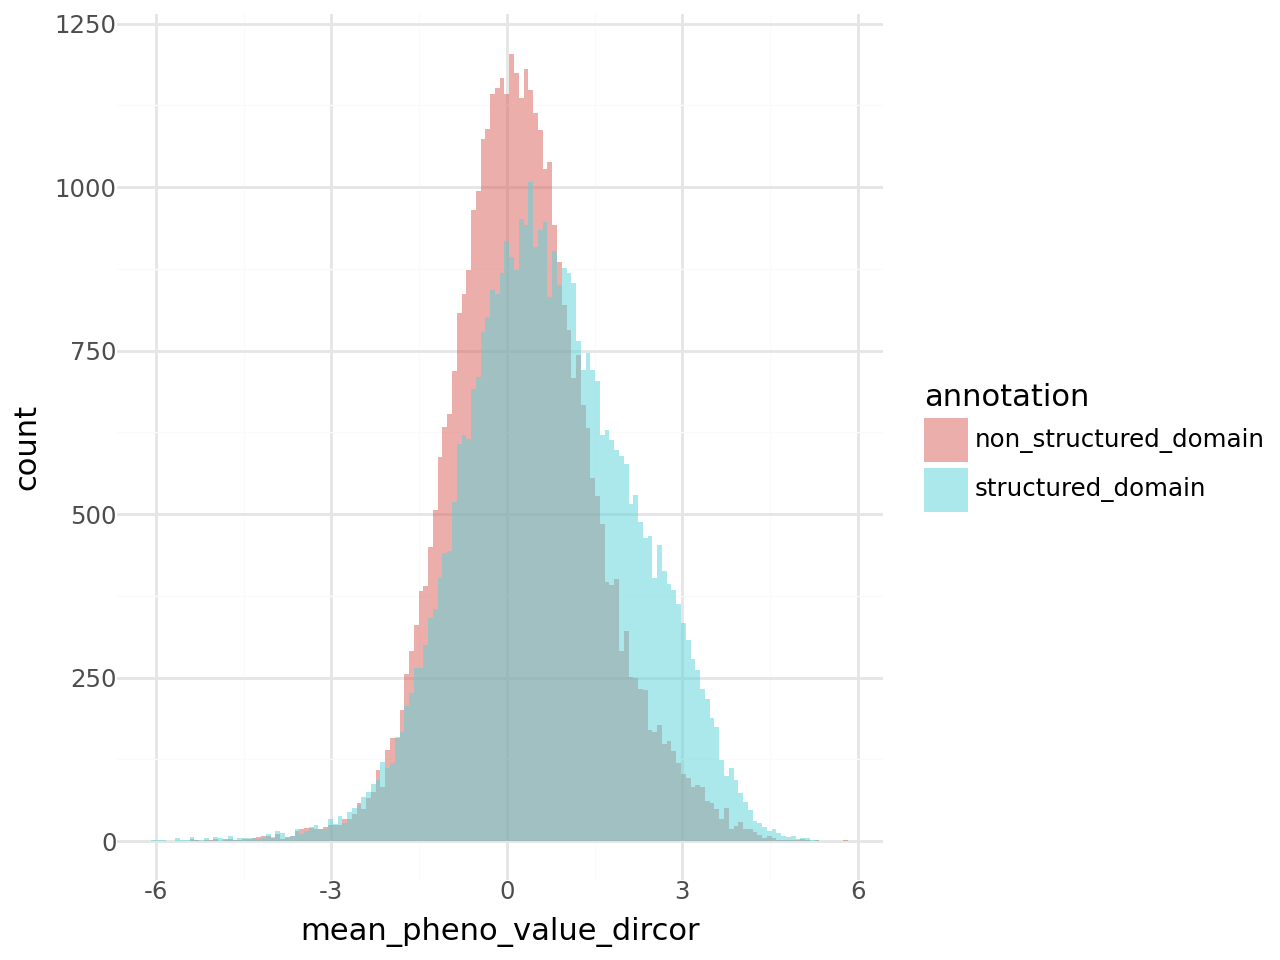

In [30]:
(
    ggplot(olink_anno.filter(pl.col('annotation_score')==True), aes(x='mean_pheno_value_dircor', fill='annotation'))
    + geom_histogram(position='identity', alpha=0.5)
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [31]:
# Phenotype quantile cutoffs — log-spaced to emphasise the extremes
# (same approach as pheno_odds_across_genes_categories.ipynb)
n_steps = 101
cutoffs_arr = (1 - np.logspace(0, -6, num=n_steps)).astype(np.float32)

cdf_cutoffs = (
    pl.DataFrame({"pheno_cutoff": cutoffs_arr.tolist()})
    .unique()
    .sort('pheno_cutoff')
)
cdf_cutoffs = cdf_cutoffs.with_columns(
    zscore_cutoff=pl.Series(stats.norm.ppf(cdf_cutoffs['pheno_cutoff'].to_numpy()))
)
cdf_cutoffs

pheno_cutoff,zscore_cutoff
f64,f64
0.0,-inf
0.129036,-1.130958
0.241422,-0.701734
0.339307,-0.414356
0.42456,-0.190241
…,…
0.999998,4.641609
0.999999,4.672178
0.999999,4.698359


In [34]:
def compute_ccdf_bootstrap(df, cutoffs, n_boot=500, seed=42):
    """
    Complementary CDF: fraction of variants ABOVE each z-score threshold,
    computed per annotation group (annotation_score==True).
    Gene-wise bootstrap resampling for 95% CIs.

    df     : columns [region, annotation, annotation_score, mean_pheno_value_dircor]
    cutoffs: columns [pheno_cutoff, zscore_cutoff]
    Returns: DataFrame [annotation, pheno_cutoff, zscore_cutoff, cdf_value, ci_lower, ci_upper]
    """
    df_pos = df.filter(pl.col('annotation_score') == True)
    annotations_list = sorted(df_pos['annotation'].unique().to_list())
    all_regions = sorted(df['region'].unique().to_list())
    n_regions = len(all_regions)
    all_regions_df = pl.DataFrame({'region': all_regions})
    n_cutoffs = cutoffs.shape[0]
    n_annos = len(annotations_list)

    # n_above[a, r, c] = #variants of type a, in gene r, with value > z-cutoff c
    # n_total[a, r]    = total #variants of type a in gene r
    n_above = np.zeros((n_annos, n_regions, n_cutoffs), dtype=np.int64)
    n_total = np.zeros((n_annos, n_regions), dtype=np.int64)

    for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
        subset = (
            df_pos
            .filter(pl.col('annotation') == annotation)
            .select(['region', 'mean_pheno_value_dircor'])
        )

        region_counts = (
            subset
            .group_by(['region', 'mean_pheno_value_dircor'])
            .agg(n=pl.len().cast(pl.Int64))
            .sort(['region', 'mean_pheno_value_dircor'])
            .with_columns(cum_n=pl.col('n').cum_sum().over('region'))
        )

        region_totals = (
            region_counts
            .group_by('region')
            .agg(total=pl.col('n').sum())
        )

        # Cross-join cutoffs × genes, then asof-join to get cumulative count at each threshold
        per_region = (
            cutoffs.lazy()
            .join(all_regions_df.lazy(), how='cross')
            .sort(['region', 'zscore_cutoff'])
            .join_asof(
                region_counts.lazy().sort(['region', 'mean_pheno_value_dircor']),
                left_on='zscore_cutoff',
                right_on='mean_pheno_value_dircor',
                by='region',
                strategy='backward',
            )
            .with_columns(cum_n=pl.col('cum_n').fill_null(0))
            .join(region_totals.lazy(), on='region', how='left')
            .with_columns(total=pl.col('total').fill_null(0))
            .with_columns(n_above_cutoff=pl.col('total') - pl.col('cum_n'))
            .sort(['region', 'pheno_cutoff'])
            .collect()
        )

        n_above[a_idx] = per_region['n_above_cutoff'].to_numpy().reshape(n_regions, n_cutoffs)
        n_total[a_idx] = (
            all_regions_df
            .join(region_totals, on='region', how='left')
            .fill_null(0)
            .sort('region')
        )['total'].to_numpy()

    # Point estimates (variant-weighted, summed across all genes)
    tot_above = n_above.sum(axis=1)         # (n_annos, n_cutoffs)
    tot_n     = n_total.sum(axis=1)[:, None] # (n_annos, 1)
    point_cdf = np.where(tot_n > 0, tot_above / tot_n, np.nan)

    # Gene-wise bootstrap for 95% CIs
    rng  = np.random.default_rng(seed)
    boot = np.full((n_boot, n_annos, n_cutoffs), np.nan)
    for b in tqdm(range(n_boot), desc='Bootstrapping'):
        idx    = rng.choice(n_regions, size=n_regions, replace=True)
        b_abv  = n_above[:, idx, :].sum(axis=1)
        b_tot  = n_total[:, idx].sum(axis=1)[:, None]
        boot[b] = np.where(b_tot > 0, b_abv / b_tot, np.nan)

    ci_lower = np.nanpercentile(boot, 2.5,  axis=0)
    ci_upper = np.nanpercentile(boot, 97.5, axis=0)

    q_vals = cutoffs['pheno_cutoff'].to_numpy()
    z_vals = cutoffs['zscore_cutoff'].to_numpy()
    ai, ci = np.meshgrid(np.arange(n_annos), np.arange(n_cutoffs), indexing='ij')

    return pl.DataFrame({
        'annotation':  np.array(annotations_list)[ai.ravel()].tolist(),
        'pheno_cutoff': q_vals[ci.ravel()].tolist(),
        'zscore_cutoff': z_vals[ci.ravel()].tolist(),
        'cdf_value':   point_cdf.ravel().tolist(),
        'ci_lower':    ci_lower.ravel().tolist(),
        'ci_upper':    ci_upper.ravel().tolist(),
    })


print("Computing phenotype CCDF...")
pheno_cdf = compute_ccdf_bootstrap(pheno_anno, cdf_cutoffs, n_boot=1000)
print("Computing Olink CCDF...")
olink_cdf = compute_ccdf_bootstrap(olink_anno, cdf_cutoffs, n_boot=1000)

Computing phenotype CCDF...


Pre-aggregating:   0%|          | 0/2 [00:00<?, ?it/s]

sys:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
Bootstrapping: 100%|██████████| 1000/1000 [00:00<00:00, 4720.37it/s]


Computing Olink CCDF...


Bootstrapping: 100%|██████████| 1000/1000 [00:00<00:00, 3072.10it/s]


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


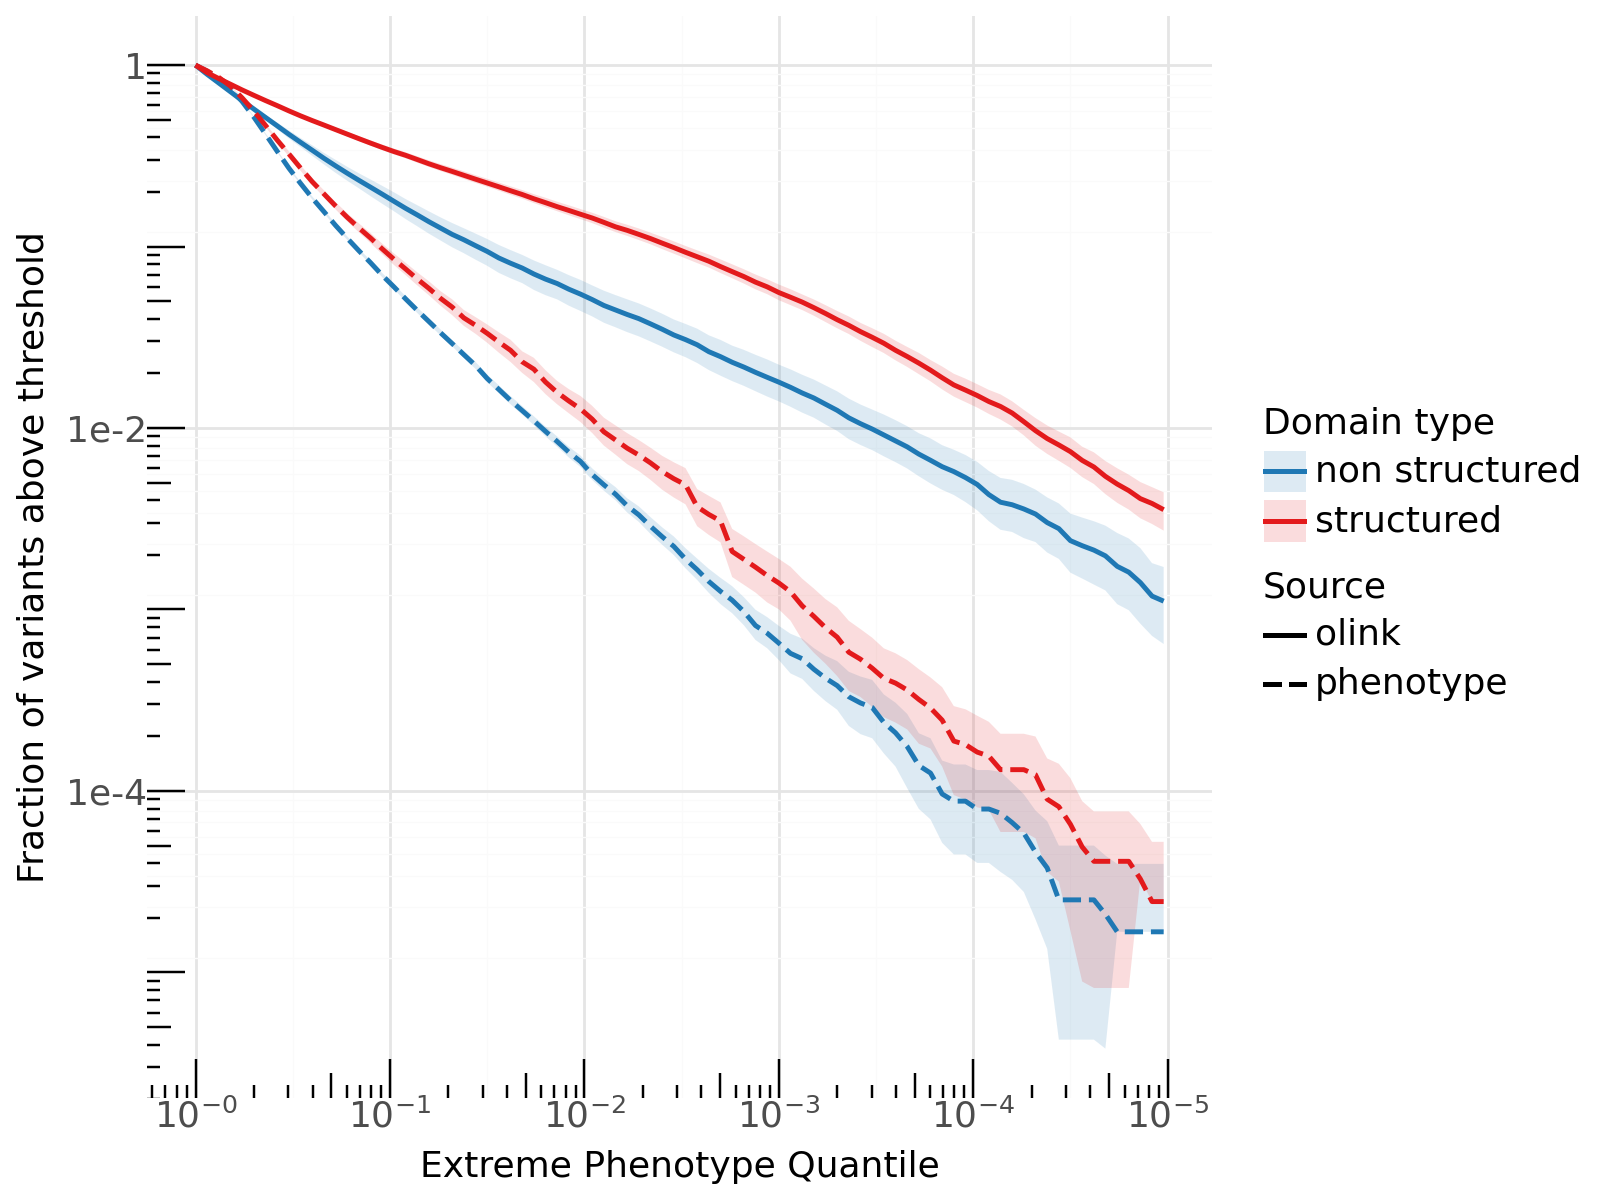

In [35]:
# Combined CCDF plot: Olink (solid) vs phenotype (dashed), structured (red) vs non-structured (blue)
# Y-axis: fraction of variants ABOVE the threshold — log scale to spread out tail differences
# X-axis: -log10(1 - quantile) — same as pheno_odds_across_genes_categories

annotation_colors = {
    'structured': '#E31A1C',
    'non structured': '#1F78B4',
}

plot_df = (
    pl.concat([
        pheno_cdf.with_columns(source=pl.lit('phenotype')),
        olink_cdf.with_columns(source=pl.lit('olink')),
    ])
    .with_columns(
        neg_log_pheno_cutoff_inv=(-np.log10(1 - pl.col('pheno_cutoff'))),
        label=(
            pl.col('annotation')
            .str.replace('_domain', '')
            .str.replace('_', ' ')
        ),
        group=pl.col('annotation') + '_' + pl.col('source'),
    )
    .with_columns(
        # Floor at a small positive value so log-y scale renders cleanly
        cdf_value=pl.when(pl.col('cdf_value') > 0).then(pl.col('cdf_value')).otherwise(None),
        ci_lower=pl.when(pl.col('ci_lower') > 0).then(pl.col('ci_lower')).otherwise(pl.col('cdf_value')),
        ci_upper=pl.when(pl.col('ci_upper') > 0).then(pl.col('ci_upper')).otherwise(pl.col('cdf_value')),
    )
    .filter(
        pl.col('neg_log_pheno_cutoff_inv').is_between(0, 5),
        pl.col('cdf_value').is_not_null(),
        pl.col('cdf_value').is_finite(),
    )
)

breaks     = np.arange(0, 6)
labels_sci = [f"$10^{{-{int(b)}}}$" for b in breaks]

(
    ggplot(plot_df, aes(x='neg_log_pheno_cutoff_inv', y='cdf_value', group='group'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.15, color='none')
    + geom_line(aes(color='label', linetype='source'), size=1)
    + scale_color_manual(values=annotation_colors)
    + scale_fill_manual(values=annotation_colors)
    + scale_linetype_manual(values={'olink': 'solid', 'phenotype': 'dashed'})
    + scale_x_continuous(breaks=breaks, labels=labels_sci)
    + scale_y_log10()
    + annotation_logticks(sides='lb')
    + labs(
        x='Extreme Phenotype Quantile',
        y='Fraction of variants above threshold',
        color='Domain type',
        fill='Domain type',
        linetype='Source',
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill='white', color='white'),
    )
)